In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [6]:
df = pd.read_csv('ai_resume_screening_dataset.csv')

In [7]:
df.head()

,candidate_id,full_name,email,phone,country,city,age,gender,highest_education,university,...,expected_salary,preferred_location,employment_type,remote_preference,availability,resume_quality_score,resume_length,keyword_match_percentage,ats_score,selected
0,CAND-000001,Allison Hill,allison.hill13@gmail.com,+1-959-381-5012,Burundi,Lake Joyside,35,Female,Master,Georgia Institute of Technology,...,172000.0,Burundi,Internship,Hybrid,30 Days,72.0,2.0,20.00,46.0,Selected
1,CAND-000002,Javier Johnson,javier.johnson58@gmail.com,+1-299-467-6635,Djibouti,New Jamesside,37,Male,Master,National University of Singapore,...,212000.0,Djibouti,Contract,Remote,Immediate,77.0,2.0,20.68,46.0,Rejected
2,CAND-000003,Jerry Ramirez,jerry.ramirez58@gmail.com,+1-476-755-4598,Senegal,Lake Roberto,41,Male,Bachelor,Massachusetts Institute of Technology,...,193000.0,Flexible,Full-Time,On-site,Immediate,58.0,2.0,62.55,65.0,Selected
3,CAND-000004,Daniel Gallagher,daniel.gallagher18@gmail.com,+1-594-490-8668,Bermuda,Davisstad,54,Male,PhD,Imperial College London,...,351000.0,Davisstad,Contract,Hybrid,Immediate,61.0,1.0,28.58,43.0,Selected
4,CAND-000005,Robert Blair,robert.blair40@hotmail.com,+1-780-180-2403,British Virgin Islands,Millerport,52,Male,PhD,National University of Singapore,...,374000.0,Millerport,Part-Time,Remote,15 Days,62.0,1.0,20.00,46.0,Selected


In [8]:
df.columns.tolist()

['candidate_id',
 'full_name',
 'email',
 'phone',
 'country',
 'city',
 'age',
 'gender',
 'highest_education',
 'university',
 'field_of_study',
 'cgpa',
 'graduation_year',
 'experience_years',
 'previous_companies',
 'current_job_title',
 'internship_experience',
 'leadership_experience',
 'technical_skills',
 'programming_languages',
 'frameworks',
 'databases',
 'cloud_platform',
 'projects_completed',
 'github_profile',
 'linkedin_profile',
 'certifications',
 'publications',
 'communication_score',
 'problem_solving_score',
 'technical_test_score',
 'interview_score',
 'aptitude_score',
 'job_role',
 'expected_salary',
 'preferred_location',
 'employment_type',
 'remote_preference',
 'availability',
 'resume_quality_score',
 'resume_length',
 'keyword_match_percentage',
 'ats_score',
 'selected']

In [9]:
df.shape

(7554, 44)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum()

,0
candidate_id,0
full_name,0
email,0
phone,0
country,0
city,0
age,0
gender,0
highest_education,0
university,0


In [12]:
df.fillna(df.mean(numeric_only=True), inplace=True)
for col in df.select_dtypes(include='object').columns:
  df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1389/1044076657.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [13]:
print(df.isna().sum().sum())

0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7554 entries, 0 to 7553
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   candidate_id              7554 non-null   object 
 1   full_name                 7554 non-null   object 
 2   email                     7554 non-null   object 
 3   phone                     7554 non-null   object 
 4   country                   7554 non-null   object 
 5   city                      7554 non-null   object 
 6   age                       7554 non-null   int64  
 7   gender                    7554 non-null   object 
 8   highest_education         7554 non-null   object 
 9   university                7554 non-null   object 
 10  field_of_study            7554 non-null   object 
 11  cgpa                      7554 non-null   float64
 12  graduation_year           7554 non-null   int64  
 13  experience_years          7554 non-null   int64  
 14  previous

In [15]:
df.dtypes

,0
candidate_id,object
full_name,object
email,object
phone,object
country,object
city,object
age,int64
gender,object
highest_education,object
university,object


In [16]:
df['candidate_id'].value_counts()

,count
candidate_id,
CAND-007554,1
CAND-000001,1
CAND-007538,1
CAND-007537,1
CAND-007536,1
...,...
CAND-000007,1
CAND-000006,1
CAND-000005,1


In [17]:
df['candidate_id'].nunique()

7554

In [18]:
df['candidate_id'].nunique() == len(df)

True

In [19]:
df.drop(columns=['candidate_id'], inplace=True)

In [20]:
df['full_name'].value_counts()

,count
full_name,
Michael Smith,8
Michael Brown,5
John Johnson,5
John Smith,4
Christopher Wright,4
...,...
Debbie Koch,1
Heather Roberts,1
Johnathan Hughes,1


In [21]:
df['full_name'].nunique()

7175

In [22]:
df['full_name'].nunique() == len(df)

False

In [23]:
freq = df['full_name'].value_counts()
df['full_name_freq'] = df['full_name'].map(freq)
df['full_name_freq'] = df['full_name'].map(freq).fillna(0).astype('int64')

In [24]:
df.drop(columns=['full_name'], inplace=True)

In [25]:
df['full_name_freq'].head()

,full_name_freq
0,1
1,1
2,1
3,1
4,1


In [26]:
df['full_name_freq'].value_counts().sort_index()

,count
full_name_freq,
1,6865
2,522
3,105
4,44
5,10
8,8


In [27]:
df['email'].value_counts()

,count
email,
ashley.mathis80@hotmail.com,1
allison.hill13@gmail.com,1
michelle.cooper99@hotmail.com,1
william.long70@hotmail.com,1
joseph.cantrell92@yahoo.com,1
...,...
scott.delacruz.md41@yahoo.com,1
luke.hensley18@hotmail.com,1
robert.blair40@hotmail.com,1


In [28]:
df['email'].nunique()

7554

In [29]:
df['email'].value_counts().describe()

,count
count,7554.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [30]:
df['email'].nunique() == len(df)

True

In [31]:
df.drop(columns=['email'], inplace=True)

In [32]:
df['phone'].value_counts()

,count
phone,
+1-435-556-5534,1
+1-959-381-5012,1
+1-771-628-8809,1
+1-743-409-3863,1
+1-367-219-6300,1
...,...
+1-277-553-2604,1
+1-232-980-6413,1
+1-780-180-2403,1


In [33]:
df['phone'].nunique()

7554

In [34]:
df['phone'].nunique() == len(df)

True

In [35]:
df.drop(columns=['phone'], inplace=True)

In [36]:
df['country'].value_counts()

,count
country,
Congo,68
Korea,63
Anguilla,47
Tunisia,45
Philippines,44
...,...
Kazakhstan,19
Taiwan,19
Hong Kong,18


In [37]:
df['country'].nunique()

243

In [38]:
country_freq = df['country'].value_counts()

df['country_freq'] = df['country'].map(country_freq).fillna(0).astype('int64')

In [39]:
df.drop(columns=['country'], inplace=True)

In [40]:
df['city'].value_counts()

,count
city,
South Michael,10
New Michael,8
East Andrew,7
Michaelmouth,7
Davidmouth,7
...,...
Newtonburgh,1
Jenningsborough,1
North Sean,1


In [41]:
df['city'].nunique()

6144

In [42]:
freq = df['city'].value_counts()

df['city_freq'] = df['city'].map(country_freq).fillna(0).astype('int64')

In [43]:
df.drop(columns=['city'], inplace=True)

In [44]:
df['gender'].value_counts()

,count
gender,
Male,3723
Female,3699
Other,132


In [45]:
df['gender'].nunique()

3

In [46]:
df['highest_education'].value_counts()

,count
highest_education,
Bachelor,4079
Master,1923
Diploma,794
PhD,401
High School,357


In [47]:
df['highest_education'].nunique()

5

In [48]:
d = {'High School':0, 'Diploma':1, 'Bachelor':2, 'Master':3, 'PhD':4}

df['highest_education'] = df['highest_education'].str.strip()

df['highest_education'] = df['highest_education'].map(d)

In [49]:
df['university'].value_counts()

,count
university,
Carnegie Mellon University,535
Georgia Institute of Technology,532
Stanford University,515
California Institute of Technology,514
University of Toronto,513
University of Cambridge,504
University of Washington,502
ETH Zurich,501
University of Oxford,497


In [50]:
df['university'].nunique()

15

In [51]:
df['field_of_study'].value_counts()

,count
field_of_study,
Mathematics & Statistics,874
Electrical Engineering,871
Cyber Security,870
Data Science,853
Software Engineering,842
Information Systems,828
Artificial Intelligence,816
Information Technology,808
Computer Science,792


In [52]:
df['field_of_study'].nunique()

9

In [53]:
df['previous_companies'].value_counts()

,count
previous_companies,
Not Applicable,1668
Stripe,79
Microsoft,79
Salesforce,78
Adobe,77
...,...
"Microsoft, Tesla, Apple, Uber",1
"Oracle, Adobe, Tesla, Databricks, IBM",1
"Amazon, NVIDIA, Apple, Palantir, Meta",1


In [54]:
df['previous_companies'].nunique()

3599

In [55]:
previous_companies_freq = df['previous_companies'].value_counts()

df['previous_companies_freq'] = df['previous_companies'].map(country_freq).fillna(0).astype('int64')

In [56]:
df.drop(columns=['previous_companies'], inplace=True)

In [57]:
df['current_job_title'].value_counts()

,count
current_job_title,
Machine Learning Engineer,517
Software Engineer,494
Database Administrator,489
AI Engineer,487
Frontend Developer,487
Mobile App Developer,480
Business Analyst,478
QA Engineer,473
UI UX Designer,470


In [58]:
df['current_job_title'].nunique()

16

In [59]:
df['internship_experience'].value_counts()

,count
internship_experience,
No,4227
Yes,3327


In [60]:
df['internship_experience'].nunique()

2

In [62]:
df.dtypes

,0
age,int64
gender,object
highest_education,int64
university,object
field_of_study,object
cgpa,float64
graduation_year,int64
experience_years,int64
current_job_title,object
internship_experience,object


In [63]:
df['leadership_experience'].value_counts()

,count
leadership_experience,
No,4250
Yes,3304


In [64]:
df['leadership_experience'].nunique()

2

In [65]:
df['technical_skills'].value_counts()

,count
technical_skills,
"Git, Angular, Vue",2
"Node.js, Git, Python",2
"NumPy, Git, Vue",2
"Angular, HTML, C++",2
"C++, JavaScript, Express",2
...,...
"TypeScript, JavaScript, Pandas, Express",1
"Docker, Azure, JavaScript, SQL, MongoDB, Pandas, Vue",1
"CSS, Scikit-learn, Django, TypeScript, React, MySQL, Azure, Flask, HTML, Vue",1


In [66]:
df['technical_skills'].nunique()

7534

In [67]:
technical_skills_freq = df['technical_skills'].value_counts()

df['technical_skills_freq'] = df['technical_skills'].map(country_freq).fillna(0).astype('int64')

In [68]:
df.drop(columns=['technical_skills'], inplace=True)

In [69]:
df['programming_languages'].value_counts()

,count
programming_languages,
Not Applicable,2261
TypeScript,639
JavaScript,627
C++,627
Java,618
...,...
"Java, TypeScript, C++, JavaScript",1
"JavaScript, TypeScript, Java, Python",1
"C++, JavaScript, TypeScript, Java",1


In [70]:
df['programming_languages'].nunique()

137

In [71]:
programming_languages_freq = df['programming_languages'].value_counts()

df['programming_languages_freq'] = df['programming_languages'].map(country_freq).fillna(0).astype('int64')

In [72]:
df.drop(columns=['programming_languages'], inplace=True)

In [73]:
df['frameworks'].value_counts()

,count
frameworks,
Not Applicable,765
Node.js,200
React,199
Vue,194
Flask,190
...,...
"Express, Scikit-learn, Django, PyTorch",1
"PyTorch, Node.js, React, Vue",1
"Node.js, PyTorch, Django",1


In [74]:
df['frameworks'].nunique()

1806

In [75]:
frameworks_freq = df['frameworks'].value_counts()

df['frameworks_freq'] = df['frameworks'].map(country_freq).fillna(0).astype('int64')

In [76]:
df.drop(columns=['frameworks'], inplace=True)

In [77]:
df['databases'].value_counts()

,count
databases,
Not Applicable,2319
Redis,653
SQL,637
MongoDB,631
PostgreSQL,588
...,...
"MongoDB, PostgreSQL, Redis, SQL",1
"PostgreSQL, Redis, MongoDB, MySQL",1
"MongoDB, Redis, SQL, MySQL",1


In [78]:
df['databases'].nunique()

138

In [79]:
databases_freq = df['databases'].value_counts()

df['databases_freq'] = df['databases'].map(country_freq).fillna(0).astype('int64')

In [80]:
df.drop(columns=['databases'], inplace=True)

In [81]:
df['cloud_platform'].value_counts()

,count
cloud_platform,
Not Applicable,2348
GCP,633
Kubernetes,625
Docker,624
Azure,623
...,...
"GCP, Docker, Kubernetes, AWS",1
"Azure, Docker, GCP, Kubernetes",1
"Azure, Docker, AWS, Kubernetes",1


In [82]:
df['cloud_platform'].nunique()

131

In [83]:
cloud_platform_freq = df['cloud_platform'].value_counts()

df['cloud_platform_freq'] = df['cloud_platform'].map(country_freq).fillna(0).astype('int64')

In [84]:
df.drop(columns=['cloud_platform'], inplace=True)

In [85]:
df.columns.to_list()

['age',
 'gender',
 'highest_education',
 'university',
 'field_of_study',
 'cgpa',
 'graduation_year',
 'experience_years',
 'current_job_title',
 'internship_experience',
 'leadership_experience',
 'projects_completed',
 'github_profile',
 'linkedin_profile',
 'certifications',
 'publications',
 'communication_score',
 'problem_solving_score',
 'technical_test_score',
 'interview_score',
 'aptitude_score',
 'job_role',
 'expected_salary',
 'preferred_location',
 'employment_type',
 'remote_preference',
 'availability',
 'resume_quality_score',
 'resume_length',
 'keyword_match_percentage',
 'ats_score',
 'selected',
 'full_name_freq',
 'country_freq',
 'city_freq',
 'previous_companies_freq',
 'technical_skills_freq',
 'programming_languages_freq',
 'frameworks_freq',
 'databases_freq',
 'cloud_platform_freq']

In [87]:
df.dtypes

,0
age,int64
gender,object
highest_education,int64
university,object
field_of_study,object
cgpa,float64
graduation_year,int64
experience_years,int64
current_job_title,object
internship_experience,object


In [91]:
df['github_profile'].value_counts()

,count
github_profile,
https://github.com/christopher._994,3
https://github.com/christopher._895,2
https://github.com/patricia.san_264,2
https://github.com/christopher._159,2
https://github.com/christopher._592,2
...,...
https://github.com/john.jones_348,1
https://github.com/jennifer.fre_285,1
https://github.com/casey.mcknig_612,1


In [92]:
df['github_profile'].nunique()

7542

In [93]:
df['linkedin_profile'].value_counts()

,count
linkedin_profile,
https://linkedin.com/in/christopher.-9531,2
https://linkedin.com/in/jennifer.sta-6547,1
https://linkedin.com/in/sarah.johnso-7624,1
https://linkedin.com/in/guy.rice-5380,1
https://linkedin.com/in/eric.ho-6192,1
...,...
https://linkedin.com/in/alexandra.ch-1504,1
https://linkedin.com/in/john.jones-5207,1
https://linkedin.com/in/jennifer.fre-2835,1


In [94]:
df['linkedin_profile'].nunique()

7553

In [95]:
df.drop(columns=['github_profile', 'linkedin_profile'], inplace=True)

In [96]:
df['certifications'].value_counts()

,count
certifications,
Not Applicable,3071
TensorFlow Developer Certificate,268
Google Cloud Professional Data Engineer,265
Certified Information Systems Security Professional (CISSP),262
Microsoft Certified: Azure Fundamentals,256
...,...
"Google Cloud Professional Data Engineer, HashiCorp Certified: Terraform Associate, Oracle Certified Professional Java SE",1
"AWS Certified Solutions Architect, AWS Certified Developer, Certified Kubernetes Administrator (CKA)",1
"Project Management Professional (PMP), AWS Certified Developer, Certified Kubernetes Administrator (CKA)",1


In [97]:
df['certifications'].nunique()

482

In [98]:
# Split certifications into lists
df['certifications'] = df['certifications'].str.split(', ')

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

cert_df = pd.DataFrame(
    mlb.fit_transform(df['certifications']),
    columns=mlb.classes_,
    index=df.index
)

# Merge and drop original column
df = pd.concat([df, cert_df], axis=1)
df.drop(columns=['certifications'], inplace=True)

In [99]:
df['job_role'].value_counts()

,count
job_role,
Machine Learning Engineer,541
Frontend Developer,523
Database Administrator,519
AI Engineer,517
Software Engineer,517
Mobile App Developer,511
UI UX Designer,504
Data Scientist,504
Business Analyst,503


In [100]:
df['job_role'].nunique()

15

In [101]:
df['preferred_location'].value_counts()

,count
preferred_location,
Flexible,1933
International,1891
Congo,20
Australia,18
Korea,16
...,...
Stonemouth,1
Amandaview,1
North Aaronton,1


In [103]:
df['preferred_location'].nunique()

2052

In [104]:
location_freq = df['preferred_location'].value_counts()

df['preferred_location_freq'] = (
    df['preferred_location']
    .map(location_freq)
    .fillna(0)
    .astype('int64')
)

# Drop the original column
df.drop(columns=['preferred_location'], inplace=True)

In [105]:
df['employment_type'].value_counts()

,count
employment_type,
Full-Time,1953
Part-Time,1895
Internship,1854
Contract,1852


In [106]:
df['employment_type'].nunique()

4

In [107]:
df['remote_preference'].value_counts()

,count
remote_preference,
Remote,2569
Hybrid,2520
On-site,2465


In [108]:
df['remote_preference'].nunique()

3

In [109]:
df['availability'].value_counts()

,count
availability,
60 Days,1564
30 Days,1535
15 Days,1509
90 Days,1488
Immediate,1458


In [110]:
df['availability'].nunique()

5

In [111]:
availability_map = {
    'Immediate': 0,
    '15 Days': 1,
    '30 Days': 2,
    '60 Days': 3,
    '90 Days': 4
}

df['availability'] = df['availability'].map(availability_map)

In [112]:
df['selected'].value_counts()

,count
selected,
Selected,3814
Rejected,3740


In [114]:
df['selected'].nunique()

2

In [115]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['selected'] = le.fit_transform(df['selected'])

In [116]:
print(le.classes_)

['Rejected' 'Selected']


In [117]:
df['selected'].unique()

array([1, 0])

In [118]:
df = pd.get_dummies(df, columns=['gender', 'university', 'field_of_study', 'current_job_title', 'internship_experience', 'leadership_experience', 'job_role', 'employment_type', 'remote_preference'], dtype='int64', drop_first=True)

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7554 entries, 0 to 7553
Data columns (total 100 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   age                                                          7554 non-null   int64  
 1   highest_education                                            7554 non-null   int64  
 2   cgpa                                                         7554 non-null   float64
 3   graduation_year                                              7554 non-null   int64  
 4   experience_years                                             7554 non-null   int64  
 5   projects_completed                                           7554 non-null   int64  
 6   publications                                                 7554 non-null   float64
 7   communication_score                                          7554 non-null   

In [120]:
print(df['selected'].describe(),
      df['selected'].skew())

count    7554.000000
mean        0.504898
std         0.500009
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: selected, dtype: float64 -0.019597100759655598


In [121]:
X = df.drop(columns=['selected'], axis=1)
y = df['selected']

In [124]:
correlation = df.corr(numeric_only=True)['selected'].sort_values(ascending=False)
print(correlation)

selected                      1.000000
experience_years              0.577190
age                           0.572905
expected_salary               0.539730
technical_test_score          0.178883
                                ...   
technical_skills_freq              NaN
programming_languages_freq         NaN
frameworks_freq                    NaN
databases_freq                     NaN
cloud_platform_freq                NaN
Name: selected, Length: 100, dtype: float64


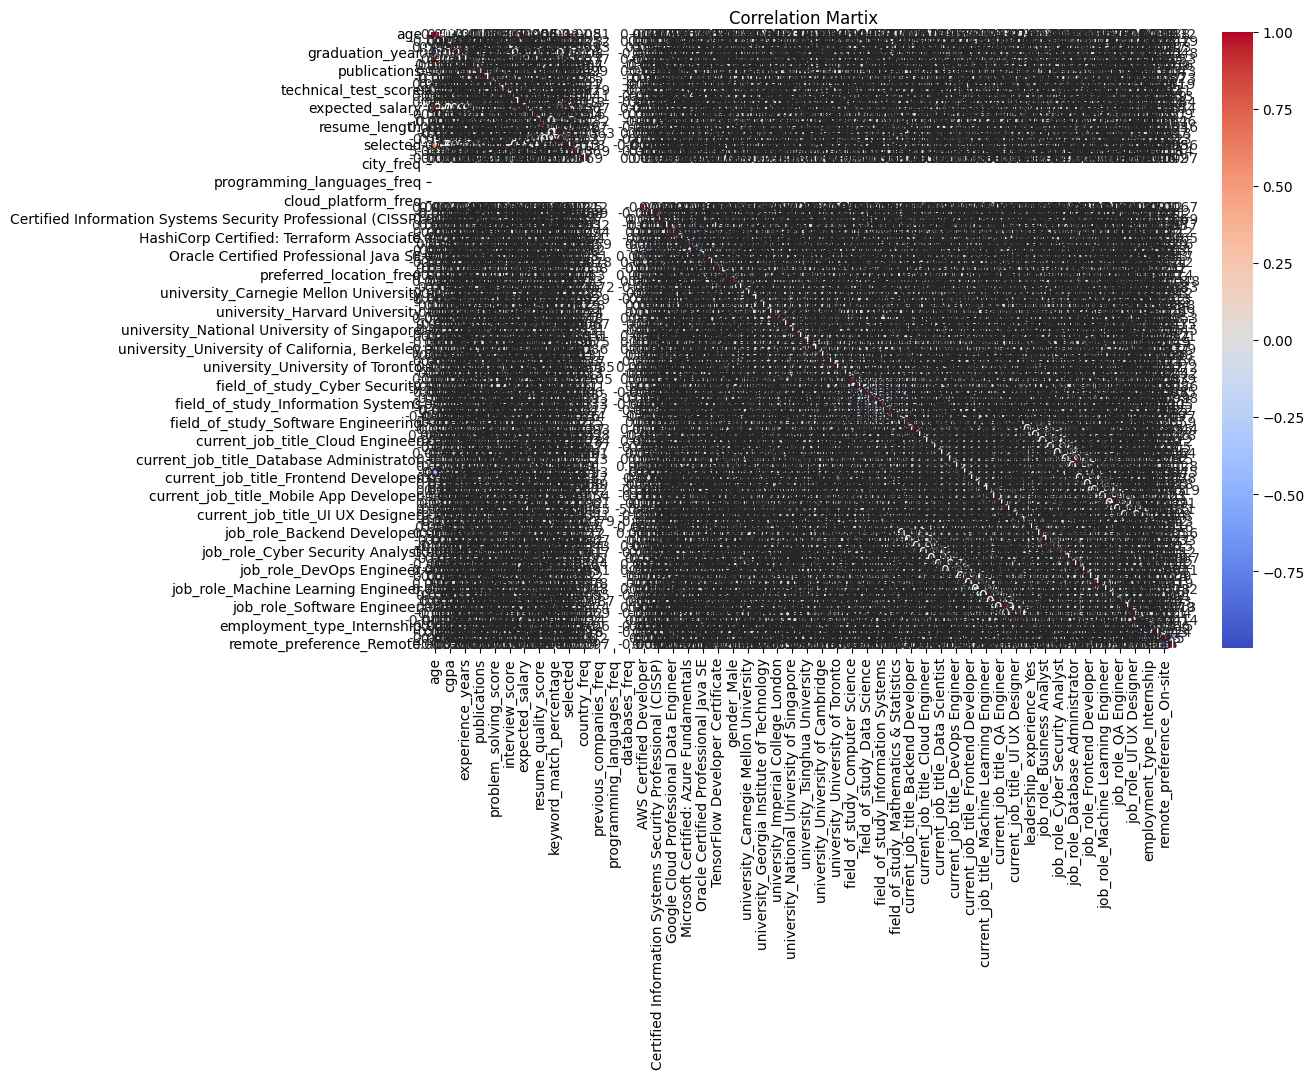

In [178]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title('Correlation Martix')
plt.show()

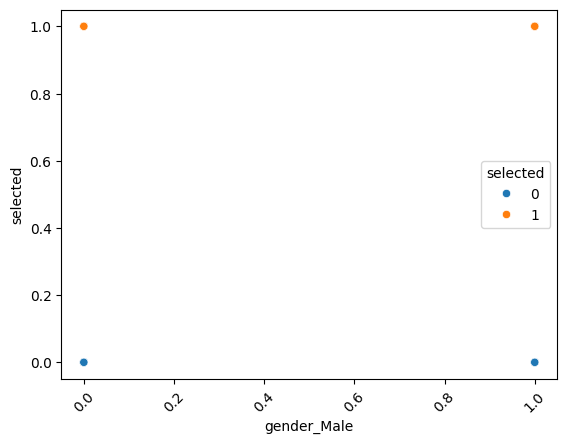

In [181]:
sns.scatterplot(
    data=df,
    x='gender_Male',
    y='selected',
    hue='selected'
)

plt.xticks(rotation=45)
plt.show()

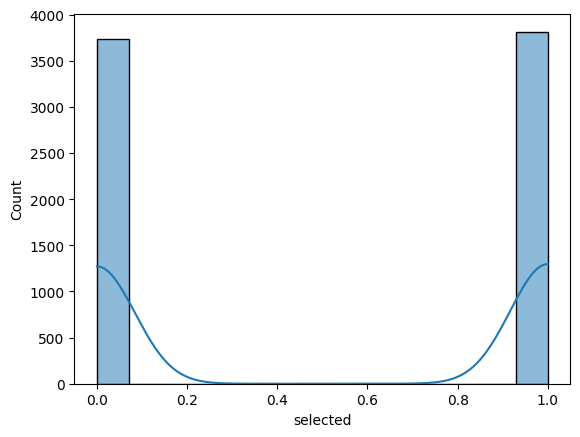

In [182]:
sns.histplot(
    data=df,
    x='selected',
    kde=True
)

plt.show()

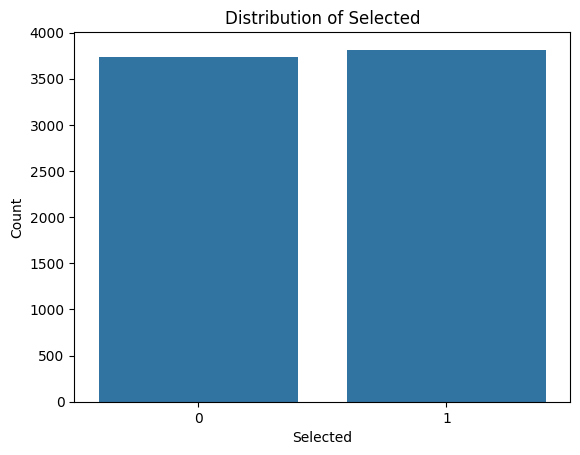

In [185]:
sns.countplot(
    data=df,
    x='selected'
)

plt.xlabel('Selected')
plt.ylabel('Count')
plt.title('Distribution of Selected')
plt.show()

In [125]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()

In [129]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [130]:
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

In [131]:
np.mean(X_train_scaled, axis=0)
np.std(X_train_scaled, axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [132]:
np.mean(X_test_scaled, axis=0)
np.std(X_test_scaled, axis=0)

array([1.00238909, 1.04404496, 1.01681655, 0.99910758, 1.00074444,
       0.98878291, 1.00217707, 1.01565907, 1.03997686, 1.00655035,
       0.99559824, 1.00113343, 0.99254277, 1.00730465, 1.00003171,
       0.99774083, 0.99085821, 0.99019481, 1.1482271 , 1.01719294,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.97137148, 0.9896591 , 1.03645978,
       0.9561083 , 1.04370762, 0.89761275, 0.943227  , 1.00211435,
       1.02035845, 1.01765095, 1.05190221, 0.99927474, 0.99927023,
       0.94368488, 0.92863732, 1.06179785, 1.01939036, 1.06517235,
       0.94540825, 1.01627166, 0.99992295, 1.0830263 , 0.99391504,
       1.0069728 , 1.0353755 , 0.92627714, 0.97380311, 0.95674818,
       0.98804355, 1.04615925, 1.01710415, 0.97413573, 0.93371813,
       1.04830532, 0.99432484, 1.01157205, 0.96554625, 1.03264112,
       0.96151432, 1.01913746, 0.94454335, 1.0773772 , 1.07946449,
       0.98507966, 1.08586402, 0.94677185, 0.96380686, 0.99992

In [140]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    random_state=42
)

In [141]:
model_log.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)

In [142]:
pred_log = model_log.predict(X_test_scaled)

In [143]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print(confusion_matrix(y_test, pred_log))
print(classification_report(y_test, pred_log))

print("ROC-AUC:", roc_auc_score(y_test, pred_log))
print("PR-AUC:", average_precision_score(y_test, pred_log))

[[596 152]
 [160 603]]
              precision    recall  f1-score   support

           0       0.79      0.80      0.79       748
           1       0.80      0.79      0.79       763

    accuracy                           0.79      1511
   macro avg       0.79      0.79      0.79      1511
weighted avg       0.79      0.79      0.79      1511

ROC-AUC: 0.7935464427639278
PR-AUC: 0.737084535446484


In [144]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [147]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model_log = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model_log.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=1000, random_state=42))])

In [148]:
print("ROC-AUC:", roc_auc_score(y_test, pred_prob))
print("PR-AUC:", average_precision_score(y_test, pred_prob))

ROC-AUC: 0.8809424520433695
PR-AUC: 0.8736637090112391


In [151]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model_log = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

scores = cross_val_score(
    model_log,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print("Mean Accuracy:", scores.mean())

[0.8266049  0.79748511 0.79814692 0.8067505  0.80662252]
Mean Accuracy: 0.8071219884204573


In [154]:
# F1 Score
scores = cross_val_score(model_log, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_log, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_log, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.8097203359976758
Mean Recall: 0.8130586887648219
Mean Balanced Accuracy: 0.8070641037406995


In [170]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [171]:
model_rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [172]:
pred_rf = model_rf.predict(X_test)
pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]

In [173]:
print(confusion_matrix(y_test, pred_rf))
print(classification_report(
    y_test,
    pred_rf,
    zero_division=0
))

[[541 207]
 [ 77 686]]
              precision    recall  f1-score   support

           0       0.88      0.72      0.79       748
           1       0.77      0.90      0.83       763

    accuracy                           0.81      1511
   macro avg       0.82      0.81      0.81      1511
weighted avg       0.82      0.81      0.81      1511



In [174]:
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_rf))

ROC-AUC: 0.907303705468843


In [175]:
scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring='f1'
)

print(scores)
print("Mean F1:", scores.mean())

[0.83916914 0.83737864 0.82471777 0.81861575 0.83214286]
Mean F1: 0.8304048310139288


In [176]:
# F1 Score
scores = cross_val_score(model_rf, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_rf, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_rf, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.8304048310139288
Mean Recall: 0.9113806875058049
Mean Balanced Accuracy: 0.8110379373357901


In [155]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [156]:
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [158]:
pred_xgb = model_xgb.predict(X_test)
pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

In [159]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, pred_xgb))
print(classification_report(
    y_test,
    pred_xgb,
    zero_division=0
))

print("ROC-AUC:", roc_auc_score(y_test, pred_proba_xgb))

[[597 151]
 [109 654]]
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       748
           1       0.81      0.86      0.83       763

    accuracy                           0.83      1511
   macro avg       0.83      0.83      0.83      1511
weighted avg       0.83      0.83      0.83      1511

ROC-AUC: 0.9183598376798594


In [160]:
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_xgb))

ROC-AUC: 0.9183598376798594


In [161]:
scores = cross_val_score(
    model_xgb,
    X,
    y,
    cv=5,
    scoring='f1'
)

print(scores)
print("Mean F1:", scores.mean())

[0.86021505 0.83994878 0.85532186 0.83408072 0.84693878]
Mean F1: 0.8473010382862377


In [162]:
# F1 Score
scores = cross_val_score(model_xgb, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_xgb, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_xgb, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.8473010382862377
Mean Recall: 0.8710016752493095
Mean Balanced Accuracy: 0.841249500726259


In [163]:
from sklearn.ensemble import GradientBoostingClassifier

model_gbr = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [164]:
model_gbr.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [165]:
pred_gbr = model_gbr.predict(X_test)
pred_proba_gbr = model_gbr.predict_proba(X_test)[:, 1]

In [166]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, pred_gbr))
print(classification_report(
    y_test,
    pred_gbr,
    zero_division=0
))

print("ROC-AUC:", roc_auc_score(y_test, pred_proba_gbr))

[[595 153]
 [100 663]]
              precision    recall  f1-score   support

           0       0.86      0.80      0.82       748
           1       0.81      0.87      0.84       763

    accuracy                           0.83      1511
   macro avg       0.83      0.83      0.83      1511
weighted avg       0.83      0.83      0.83      1511

ROC-AUC: 0.9205973465282694


In [167]:
print("ROC-AUC:", roc_auc_score(y_test, pred_proba_gbr))

ROC-AUC: 0.9205973465282694


In [168]:
scores = cross_val_score(
    model_gbr,
    X,
    y,
    cv=5,
    scoring='f1'
)

print(scores)
print("Mean F1:", scores.mean())

[0.86683417 0.84089457 0.8504436  0.83227446 0.84190715]
Mean F1: 0.8464707901662611


In [169]:
# F1 Score
scores = cross_val_score(model_gbr, X, y, cv=5, scoring='f1')
print("Mean F1:", scores.mean())

# Recall (how many frauds are detected)
scores = cross_val_score(model_gbr, X, y, cv=5, scoring='recall')
print("Mean Recall:", scores.mean())

# Balanced Accuracy
scores = cross_val_score(model_gbr, X, y, cv=5, scoring='balanced_accuracy')
print("Mean Balanced Accuracy:", scores.mean())

Mean F1: 0.8464707901662611
Mean Recall: 0.877032916756965
Mean Balanced Accuracy: 0.8390512177367715


In [191]:
import joblib

joblib.dump(
    model_xgb,
    'selected_or_rejected_model.pkl',
    compress=3
)

print('Model saved successfully')

Model saved successfully


In [192]:
model_xgb = joblib.load('selected_or_rejected_model.pkl')

print('Model loaded successfully')

Model loaded successfully


In [193]:
X.columns.tolist()

['age',
 'highest_education',
 'cgpa',
 'graduation_year',
 'experience_years',
 'projects_completed',
 'publications',
 'communication_score',
 'problem_solving_score',
 'technical_test_score',
 'interview_score',
 'aptitude_score',
 'expected_salary',
 'availability',
 'resume_quality_score',
 'resume_length',
 'keyword_match_percentage',
 'ats_score',
 'full_name_freq',
 'country_freq',
 'city_freq',
 'previous_companies_freq',
 'technical_skills_freq',
 'programming_languages_freq',
 'frameworks_freq',
 'databases_freq',
 'cloud_platform_freq',
 'AWS Certified Developer',
 'AWS Certified Solutions Architect',
 'Certified Information Systems Security Professional (CISSP)',
 'Certified Kubernetes Administrator (CKA)',
 'Google Cloud Professional Data Engineer',
 'HashiCorp Certified: Terraform Associate',
 'Microsoft Certified: Azure Fundamentals',
 'Not Applicable',
 'Oracle Certified Professional Java SE',
 'Project Management Professional (PMP)',
 'TensorFlow Developer Certificate

In [194]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [195]:
feature_columns = joblib.load("feature_columns.pkl")

In [198]:
feature_columns = joblib.load("feature_columns.pkl")